# Quantum linear solver with LCU of Chebyshev polynomials

The code here can be integrated as part of a larger CFD solver, e.g., as in [qc-cfd repository](https://github.com/rolls-royce/qc-cfd/tree/main/1D-Nozzle).
In particular, instead of calling a classical solver, e.g., `x = sparse.linalg.spsolve(mat_raw_scr, b_raw)`, one can call the quantum solver `cheb_lcu_approx_solver(mat_raw_scr, b_raw,...)`.

We implemented two versions for block-encoding, one based on Pauli decomposition of the matrix, and another one based on decomposing the matrix to a finite set of diagonals.

In [1]:
!pip install -qq "classiq[qsp]"
!pip install -qq "classiq[chemistry]"

We start with defining the functions. First we define the quantum function `lcu_cheb_approx` that implements an approximated Chebyshev LCU quantum linear solver.

In [2]:
import time

import matplotlib.pyplot as plt
import numpy as np
from banded_be import get_banded_diags_be
from cheb_utils import *
from classical_functions_be import get_svd_range
from pauli_be import get_pauli_be
from scipy import sparse

from classiq import *
from classiq.applications.qsp.qsp import poly_inversion

np.random.seed(53)

PAULI_TRIM_REL_TOL = 0.1

In [3]:
from classiq.qmod.symbolic import pi


@qfunc
def my_reflect_about_zero(qba: QNum):
    reflect_about_zero(qba)
    phase(pi)


@qfunc
def walk_operator(
    block_enc: QCallable[QArray, QArray], block: QArray, data: QArray
) -> None:
    block_enc(block, data)
    my_reflect_about_zero(block)


@qfunc
def symmetrize_walk_operator(
    block_enc: QCallable[QNum, QArray], block: QNum, data: QArray
):
    my_reflect_about_zero(block)
    within_apply(
        lambda: block_enc(block, data),
        lambda: my_reflect_about_zero(block),
    )


@qfunc
def lcu_cheb_approx(
    powers: CArray[CInt],
    inv_coeffs: CArray[CReal],
    sp_error: CReal,
    block_enc: QCallable[QNum, QArray],
    mat_block: QNum,
    data: QArray,
    cheb_block: QArray,
) -> None:

    within_apply(
        lambda: inplace_prepare_state(inv_coeffs, sp_error, cheb_block),
        lambda: (
            Z(cheb_block[0]),
            repeat(
                powers.len,
                lambda i: control(
                    cheb_block[i],
                    lambda: power(
                        powers[i],
                        lambda: symmetrize_walk_operator(block_enc, mat_block, data),
                    ),
                ),
            ),
            my_reflect_about_zero(mat_block),
            walk_operator(block_enc, mat_block, data),
        ),
    )

Next, we define the `cheb_lcu_approx_solver` function, which gets the matrix and right-hand-side vector, applies the quantum solver, and returns the linear equation solution using a statevector simulator. The solvers in this directory were developed in the framework of exploring their performance in hybrid CFD schemes. For simplicity, it is assumed that all the properties of the matrices are known explicitly. In particular, we calculate its singular values for identifying the range in which we apply the inversion polynomial.

In [4]:
def cheb_lcu_approx_solver(
    mat_raw_scr,
    b_raw,
    log_poly_degree,
    be_method="banded",
    approximation=0,
    preferences=Preferences(),
    constraints=Constraints(),
):

    scale = 0.5
    b_norm = np.linalg.norm(b_raw)
    b_normalized = b_raw / b_norm
    data_size = max(1, (len(b_raw) - 1).bit_length())

    if be_method == "pauli":
        data_size, block_size, be_scaling_factor, be_qfunc = get_pauli_be(mat_raw_scr)
    if be_method == "banded":
        data_size, block_size, be_scaling_factor, be_qfunc = get_banded_diags_be(
            mat_raw_scr
        )

    w_min, w_max = get_svd_range(mat_raw_scr / be_scaling_factor)
    poly_degree = 2 * (2**log_poly_degree - 1) + 1
    c, m = poly_inversion(poly_degree, 1 / w_min, "relative")
    pcoefs, poly_scale = scale * c / m, scale / m

    odd_coef = pcoefs[1::2]
    if approximation > 0:
        odd_coef = fit_linear_coeffs_for_cheb(pcoefs)

    lcu_size_inv = len(odd_coef).bit_length() - 1
    print(f"Chebyshev LCU size: {lcu_size_inv} qubits.")
    odd_coeffs_signs = np.sign(odd_coef)
    assert np.all(
        odd_coeffs_signs == np.where(np.arange(len(odd_coeffs_signs)) % 2 == 0, 1, -1)
    ), "Non alternating signs for odd coefficients"
    normalization_inv = sum(np.abs(odd_coef))
    print(f"Normalization factor for inversion: {normalization_inv}")
    prepare_probs_inv = (np.abs(odd_coef) / normalization_inv).tolist()

    @qfunc
    def main(
        matrix_block: Output[QNum[block_size]],
        data: Output[QNum[data_size]],
        inv_block: Output[QNum[lcu_size_inv]],
    ):
        allocate(inv_block)
        allocate(matrix_block)
        prepare_amplitudes(b_normalized.tolist(), 0, data)
        lcu_cheb_approx(
            powers=[2**i for i in range(lcu_size_inv)],
            inv_coeffs=prepare_probs_inv,
            sp_error=approximation,
            block_enc=lambda b, d: invert(lambda: be_qfunc(b, d)),
            mat_block=matrix_block,
            data=data,
            cheb_block=inv_block,
        )

    start_time_syn = time.time()
    qprog = synthesize(main, preferences=preferences, constraints=constraints)
    print("time to syn:", time.time() - start_time_syn)

    start_time_exe = time.time()
    sv = calculate_state_vector(qprog, filters={"matrix_block": 0, "inv_block": 0})
    proj_statevector = np.zeros(2**data_size, dtype=complex)
    proj_statevector[sv["data"].to_numpy()] = sv["amplitude"].to_numpy()
    indices = np.where(np.abs(proj_statevector) > 1e-13)[0]
    if len(indices) > 0:
        global_phase = np.angle(proj_statevector[indices[0]])
        resulting_state = np.real(proj_statevector / np.exp(1j * global_phase))
    else:
        resulting_state = np.zeros(2**data_size)
    print("time to exe:", time.time() - start_time_exe)

    normalization_factor = (be_scaling_factor * poly_scale) / b_norm / normalization_inv
    return resulting_state / normalization_factor, qprog

In [5]:
import pathlib

path = (
    pathlib.Path(__file__).parent.resolve()
    if "__file__" in locals()
    else pathlib.Path(".")
)

We examine two usecases, starting with a small one, and applying a Pauli-LCU block encoding.

In [6]:
mat_small_scr = sparse.load_npz(path / "matrices/nozzle_small_scr.npz")
b_small = np.load(path / "matrices/b_nozzle_small.npy")
print(f"nozzle_small: {mat_small_scr.shape[0]}x{mat_small_scr.shape[1]}")

nozzle_small: 8x8


In [7]:
prefs = Preferences()

In [8]:
qsol_small_pauli, qprog_small_pauli = cheb_lcu_approx_solver(
    mat_small_scr,
    b_small,
    log_poly_degree=4,
    be_method="pauli",
    preferences=prefs,
    constraints=Constraints(optimization_parameter="width"),
)
show(qprog_small_pauli)

number of Paulis before/after trimming 24/20
Chebyshev LCU size: 4 qubits.
Normalization factor for inversion: 0.7082716135217179


Submitting job to simulator


time to syn: 73.70448398590088


Job: https://platform.classiq.io/jobs/b5381f72-ce8a-470c-b42e-220fb2bfcb12


time to exe: 17.767388105392456
Quantum program link: https://platform.classiq.io/circuit/3Dt1koIunNqabP53yYwcvdon8Cn


We plot the solution vector, and compare to the expected classical result:

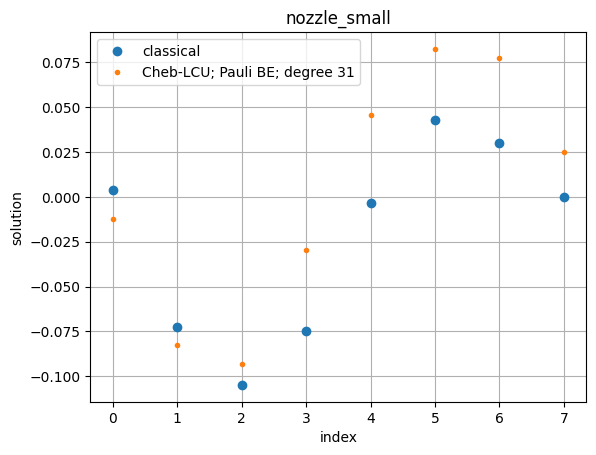

In [9]:
expected_small = np.linalg.solve(mat_small_scr.toarray(), b_small)
ext_idx = np.argmax(np.abs(expected_small))
correct_sign = np.sign(expected_small[ext_idx]) / np.sign(qsol_small_pauli[ext_idx])
qsol_small_pauli *= correct_sign
plt.plot(expected_small, "o", label="classical")
plt.plot(qsol_small_pauli, ".", label=f"Cheb-LCU; Pauli BE; degree {2*2**4-1}")
plt.title("nozzle_small")
plt.xlabel("index")
plt.ylabel("solution")
plt.legend()
plt.grid(True)
plt.show()

In [10]:
assert np.linalg.norm(qsol_small_pauli - expected_small) < 0.2

Next, we move to a larger problem. In a hybrid algorithm, we can relax some of the synthesis preferences to obtain the result a faster (for example, we can set `debug_mode=False` as we can skip the visualization of the quantum program).
For the larger usecase we work with the Banded Diagonals block-encoding. We compare the approximated version of the solver to the exact one.

In [11]:
mat_008_scr = sparse.load_npz(path / "matrices/nozzle_008_mat.npz")
b_008 = np.load(path / "matrices/nozzle_008_b.npy")
print(f"nozzle_008:   {mat_008_scr.shape[0]}x{mat_008_scr.shape[1]}")

nozzle_008:   16x16


In [12]:
prefs = Preferences(
    transpilation_option="none",
    optimization_level=0,
    debug_mode=False,
    qasm3=True,
)

In [13]:
qsol_008_banded, qprog_008_banded = cheb_lcu_approx_solver(
    mat_008_scr,
    b_008,
    log_poly_degree=7,
    be_method="banded",
    preferences=prefs,
    constraints=Constraints(optimization_parameter="width"),
)

Chebyshev LCU size: 7 qubits.
Normalization factor for inversion: 0.8180186976736218


Submitting job to simulator


time to syn: 48.63558340072632


Job: https://platform.classiq.io/jobs/3a7ef91e-b24f-4f49-bebb-b7e9fecf2d8e


time to exe: 70.26255297660828


In [14]:
SP_APPROX_BOUND = 0.03
qsol_008_banded_approx, qprog_008_banded_approx = cheb_lcu_approx_solver(
    mat_008_scr,
    b_008,
    log_poly_degree=7,
    be_method="banded",
    approximation=SP_APPROX_BOUND,
    preferences=prefs,
    constraints=Constraints(optimization_parameter="width"),
)

linear fit parameters: slope = -0.00010397734302726349, b= 0.014094618961514994
Chebyshev LCU size: 7 qubits.
Normalization factor for inversion: 0.9589833829483215


Submitting job to simulator


time to syn: 48.173218727111816


Job: https://platform.classiq.io/jobs/9ab42c87-977a-4d4f-a5c8-e5841d5c9eaa


time to exe: 71.8209617137909


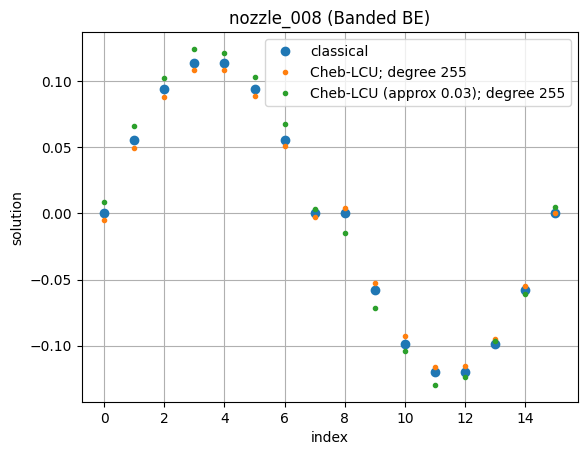

In [17]:
expected_008 = np.linalg.solve(mat_008_scr.toarray(), b_008)
ext_idx = np.argmax(np.abs(expected_008))
correct_sign = np.sign(expected_008[ext_idx]) / np.sign(qsol_008_banded[ext_idx])
qsol_008_banded *= correct_sign
plt.plot(expected_008, "o", label="classical")
plt.plot(qsol_008_banded, ".", label=f"Cheb-LCU; degree {2*2**7-1}")
correct_sign = np.sign(expected_008[ext_idx]) / np.sign(qsol_008_banded_approx[ext_idx])
qsol_008_banded_approx *= correct_sign
plt.plot(
    qsol_008_banded_approx,
    ".",
    label=f"Cheb-LCU (approx {SP_APPROX_BOUND}); degree {2*2**7-1}",
)
plt.title("nozzle_008 (Banded BE)")
plt.xlabel("index")
plt.ylabel("solution")
plt.legend()
plt.grid(True)
plt.show()

In [16]:
assert np.linalg.norm(qsol_008_banded - expected_008) < 0.1
assert np.linalg.norm(qsol_008_banded_approx - expected_008) < 0.1